# Chapitre 4 : seuil, coûts, ROC et calibration

Jeu simulé déséquilibré : régression logistique, recherche du seuil minimisant un coût asymétrique, courbes ROC et calibration.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=3000,
    n_features=8,
    weights=[0.85, 0.15],
    random_state=42,
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=5000)),
    ]
)
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]
print("Positifs test:", y_test.sum(), "/", len(y_test))

Positifs test: 139 / 900


## Coût total en fonction du seuil τ

Seuil optimal (c_fp=1.0, c_fn=8.0): tau ≈ 0.46
Matrice au seuil optimal:
[[742  19]
 [  5 134]]


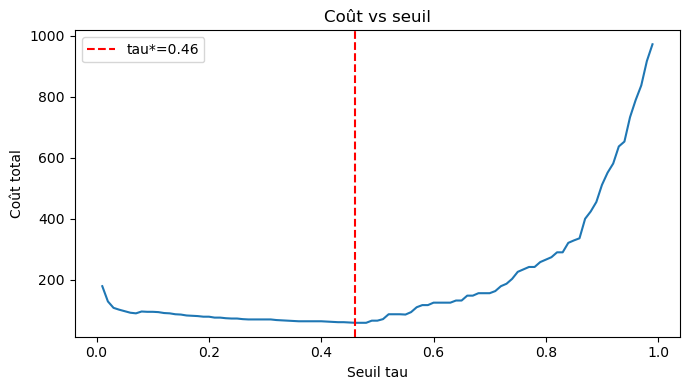

In [2]:
c_fp, c_fn = 1.0, 8.0
thresholds = np.linspace(0.01, 0.99, 99)
costs = []
for t in thresholds:
    pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    costs.append(c_fp * fp + c_fn * fn)

best_i = int(np.argmin(costs))
t_star = thresholds[best_i]
print(f"Seuil optimal (c_fp={c_fp}, c_fn={c_fn}): tau ≈ {t_star:.2f}")
print("Matrice au seuil optimal:")
print(confusion_matrix(y_test, (proba >= t_star).astype(int)))

plt.figure(figsize=(7, 4))
plt.plot(thresholds, costs)
plt.axvline(t_star, color="r", linestyle="--", label=f"tau*={t_star:.2f}")
plt.xlabel("Seuil tau")
plt.ylabel("Coût total")
plt.legend()
plt.title("Coût vs seuil")
plt.tight_layout()
plt.show()

## ROC et calibration

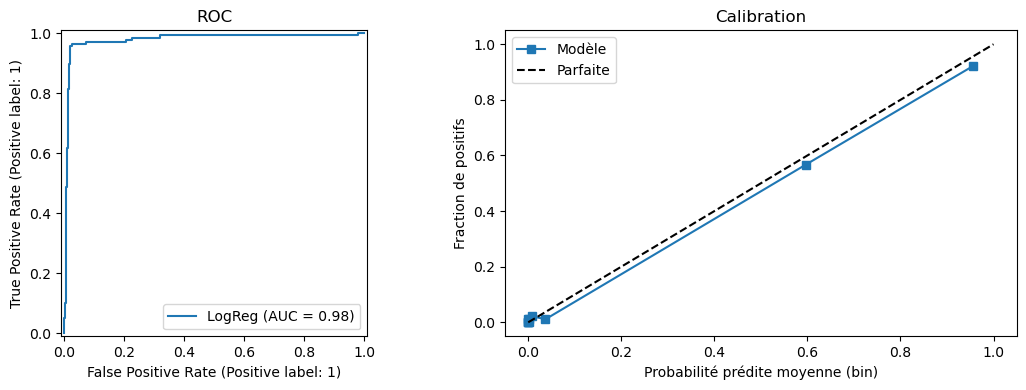

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[0], name="LogReg")
axes[0].set_title("ROC")

prob_true, prob_pred = calibration_curve(
    y_test, proba, n_bins=10, strategy="quantile"
)
axes[1].plot(prob_pred, prob_true, "s-", label="Modèle")
axes[1].plot([0, 1], [0, 1], "k--", label="Parfaite")
axes[1].set_xlabel("Probabilité prédite moyenne (bin)")
axes[1].set_ylabel("Fraction de positifs")
axes[1].set_title("Calibration")
axes[1].legend()
plt.tight_layout()
plt.show()